
# Machine Learning Assignment - 1
# Bike Sharing Demand Prediction

## Student: Pankaj Singh Rawat

---

# Objective

The objective of this assignment is to predict hourly bike rental demand using:

- Weather information
- Seasonal information
- Time-based variables

The assignment focuses on:

- Exploratory Data Analysis (EDA)
- Feature Engineering
- Linear Regression
- Polynomial Regression
- Ridge Regression
- Lasso Regression
- RMSLE Evaluation

---

# Important Leakage Observation

The columns:

- `casual`
- `registered`

directly sum up to:

\[
count = casual + registered
\]

Using these variables would create data leakage because they reveal the target directly.

Therefore, these columns are removed before model training.


## Import Libraries

In [1]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 100)


## Load Dataset

In [2]:

df = pd.read_csv('bike_train.csv')

print("Dataset Shape:", df.shape)

df.head()


Dataset Shape: (10450, 12)


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2012-07-15 7:00:00,3,0,0,1,28.70000,33.335000,79,6.003200,17,30,47
1,2012-08-14 15:00:00,3,0,1,1,33.62000,37.880000,46,15.001300,84,199,283
2,2011-02-06 6:00:00,1,0,0,1,10.66000,12.880000,60,15.001300,0,1,1
3,2012-05-06 17:00:02,2,0,0,2,26.42506,30.566166,61,9.512288,198,330,531
4,2012-01-09 2:00:00,1,0,1,1,9.84000,12.120000,56,8.998100,2,3,5



# Q1. Examine Dataset Size, Missing Values, and Feature Types


In [3]:

print("Missing Values")
display(df.isnull().sum())

print("\nData Types")
display(df.dtypes)

print("\nSummary Statistics")
display(df.describe().T)


Missing Values


datetime      0
season        0
holiday       0
workingday    0
weather       0
temp          0
atemp         0
humidity      0
windspeed     0
casual        0
registered    0
count         0
dtype: int64


Data Types


datetime          str
season          int64
holiday         int64
workingday      int64
weather         int64
temp          float64
atemp         float64
humidity        int64
windspeed     float64
casual          int64
registered      int64
count           int64
dtype: object


Summary Statistics


,count,mean,std,min,25%,50%,75%,max
season,10450.0,2.507943,1.116946,1.00,2.0000,3.00000,4.0000,4.0000
holiday,10450.0,0.028804,0.167263,0.00,0.0000,0.00000,0.0000,1.0000
workingday,10450.0,0.675694,0.468137,0.00,0.0000,1.00000,1.0000,1.0000
weather,10450.0,1.413876,0.632258,1.00,1.0000,1.00000,2.0000,4.0000
temp,10450.0,20.191700,7.792683,0.82,13.9400,20.50000,26.2400,41.0000
atemp,10450.0,23.605793,8.478045,0.76,16.6650,24.24000,31.0600,45.4550
humidity,10450.0,61.924211,19.245193,0.00,47.0000,62.00000,77.0000,100.0000
windspeed,10450.0,12.765259,8.102821,0.00,7.0015,12.45005,16.9979,56.9969
casual,10450.0,35.869091,49.629436,0.00,4.0000,16.00000,49.0000,367.0000
registered,10450.0,154.511675,150.861267,0.00,35.0000,117.00000,221.0000,886.0000



## Observations

- The dataset is clean with no missing values.
- Both numerical and categorical variables are present.
- The target variable `count` is right-skewed.
- `datetime` must be converted into datetime format.



# Feature Engineering


In [4]:

# Remove leakage columns
df = df.drop(columns=['casual', 'registered'])

# Convert datetime
df['datetime'] = pd.to_datetime(df['datetime'])

# Extract features
df['year'] = df['datetime'].dt.year
df['month'] = df['datetime'].dt.month
df['hour'] = df['datetime'].dt.hour
df['weekday'] = df['datetime'].dt.weekday

# Peak commute hours
df['is_peak_hour'] = df['hour'].isin(
    [7,8,9,17,18,19]
).astype(int)

# Weekend feature
df['is_weekend'] = (df['weekday'] >= 5).astype(int)

# Working day interaction
df['workingday_peak'] = (
    df['workingday'] * df['is_peak_hour']
)

# Cyclical encoding
df['hour_sin'] = np.sin(2*np.pi*df['hour']/24)
df['hour_cos'] = np.cos(2*np.pi*df['hour']/24)

df['weekday_sin'] = np.sin(2*np.pi*df['weekday']/7)
df['weekday_cos'] = np.cos(2*np.pi*df['weekday']/7)

df['month_sin'] = np.sin(2*np.pi*df['month']/12)
df['month_cos'] = np.cos(2*np.pi*df['month']/12)

df.head()


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,count,year,month,hour,weekday,is_peak_hour,is_weekend,workingday_peak,hour_sin,hour_cos,weekday_sin,weekday_cos,month_sin,month_cos
0,2012-07-15 07:00:00,3,0,0,1,28.70000,33.335000,79,6.003200,47,2012,7,7,6,1,1,0,0.965926,-2.588190e-01,-0.781831,0.62349,-0.500000,-0.866025
1,2012-08-14 15:00:00,3,0,1,1,33.62000,37.880000,46,15.001300,283,2012,8,15,1,0,0,0,-0.707107,-7.071068e-01,0.781831,0.62349,-0.866025,-0.500000
2,2011-02-06 06:00:00,1,0,0,1,10.66000,12.880000,60,15.001300,1,2011,2,6,6,0,1,0,1.000000,6.123234e-17,-0.781831,0.62349,0.866025,0.500000
3,2012-05-06 17:00:02,2,0,0,2,26.42506,30.566166,61,9.512288,531,2012,5,17,6,1,1,0,-0.965926,-2.588190e-01,-0.781831,0.62349,0.500000,-0.866025
4,2012-01-09 02:00:00,1,0,1,1,9.84000,12.120000,56,8.998100,5,2012,1,2,0,0,0,0,0.500000,8.660254e-01,0.000000,1.00000,0.500000,0.866025



## Why These Features Help

Bike rental demand strongly depends on:

- commuting behavior
- weekdays vs weekends
- time cycles
- seasonal patterns

Cyclical encoding helps preserve continuity between:
- hour 23 and hour 0
- Sunday and Monday
- December and January



# Q2. Visualize Relationships Between Features and Target


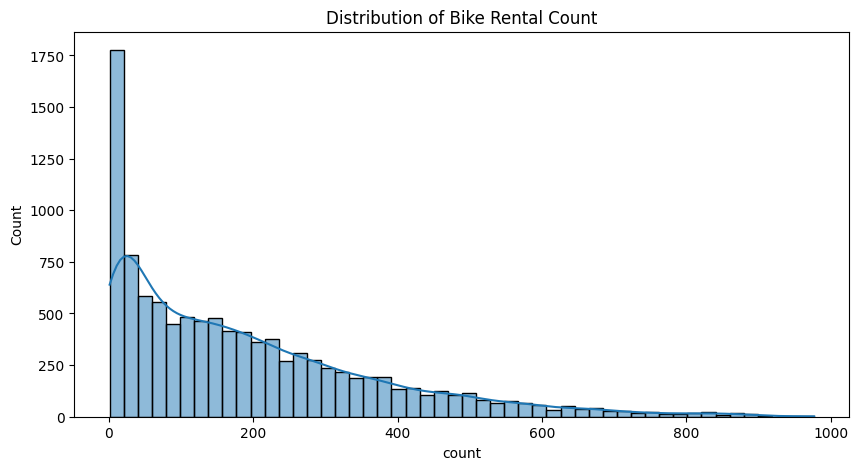

In [5]:

plt.figure(figsize=(10,5))

sns.histplot(df['count'], bins=50, kde=True)

plt.title('Distribution of Bike Rental Count')

plt.show()


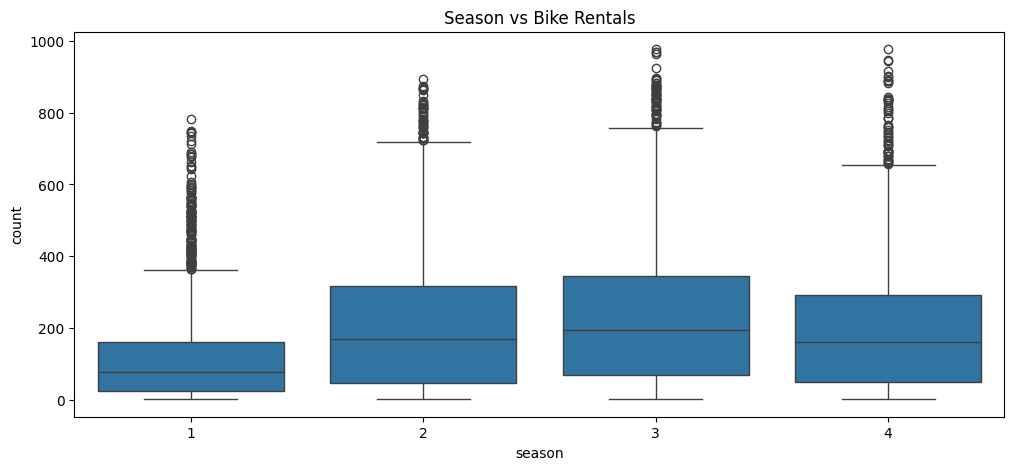

In [6]:

plt.figure(figsize=(12,5))

sns.boxplot(x='season', y='count', data=df)

plt.title('Season vs Bike Rentals')

plt.show()


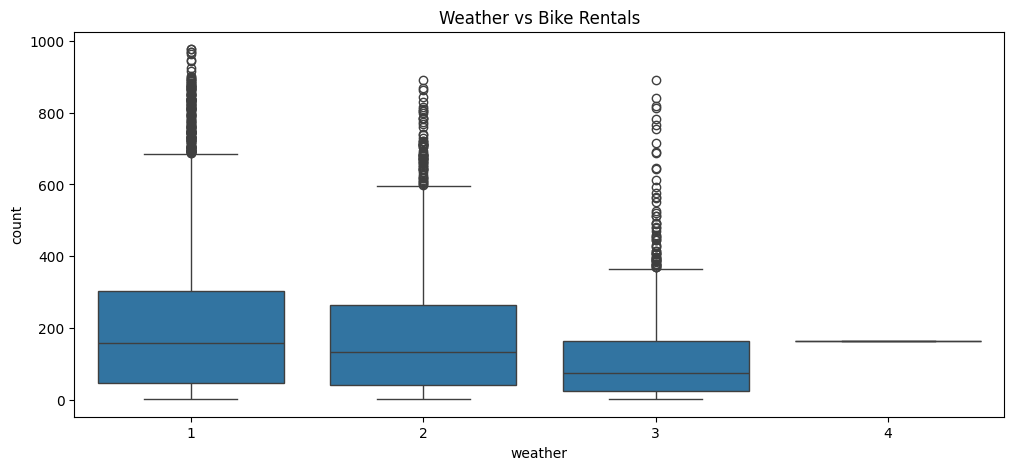

In [7]:

plt.figure(figsize=(12,5))

sns.boxplot(x='weather', y='count', data=df)

plt.title('Weather vs Bike Rentals')

plt.show()


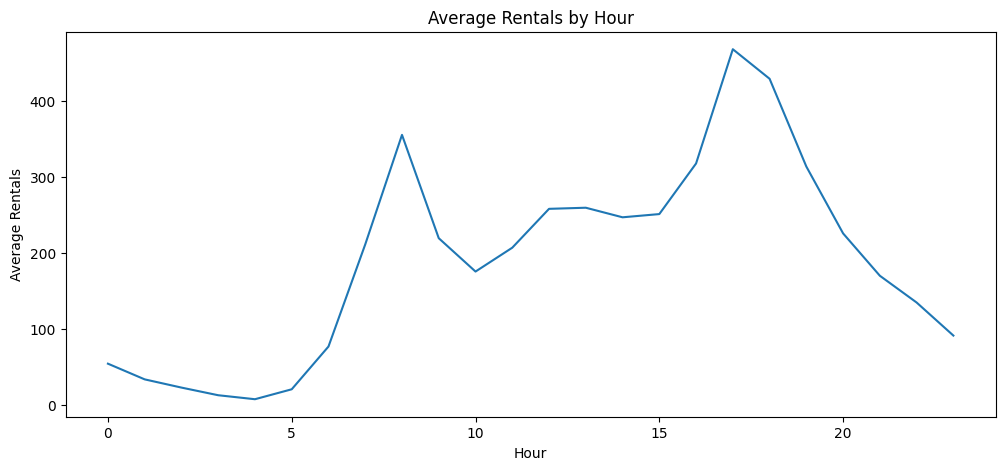

In [8]:

hourly_avg = df.groupby('hour')['count'].mean()

plt.figure(figsize=(12,5))

plt.plot(hourly_avg.index, hourly_avg.values)

plt.title('Average Rentals by Hour')

plt.xlabel('Hour')
plt.ylabel('Average Rentals')

plt.show()



# Q3. Most Informative Variables

The most informative variables are:

- hour
- weather
- season
- humidity
- temperature
- workingday
- peak hour indicators
- cyclical time features

These variables strongly influence bike demand patterns.



# Prepare Data for Modeling


In [9]:

selected_features = [
    'season',
    'holiday',
    'workingday',
    'weather',
    'temp',
    'humidity',
    'windspeed',
    'is_peak_hour',
    'is_weekend',
    'workingday_peak',
    'hour_sin',
    'hour_cos',
    'weekday_sin',
    'weekday_cos',
    'month_sin',
    'month_cos'
]

X = df[selected_features]

# Log transform for RMSLE optimization
y = np.log1p(df['count'])

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_val.shape)


(8360, 16)
(2090, 16)



## Why Log Transformation Helps

RMSLE is based on logarithmic differences.

Training on:

\[
log(1 + count)
\]

helps:
- reduce skewness
- stabilize variance
- improve RMSLE performance


In [10]:

def rmsle(y_true, y_pred):

    y_pred = np.maximum(0, y_pred)

    return np.sqrt(
        np.mean(
            (np.log1p(y_pred) - np.log1p(y_true))**2
        )
    )



# Q5 & Q6. Build Regression Models


In [11]:

results = []
model_predictions = {}

def evaluate_model(model, model_name):

    model.fit(X_train, y_train)

    train_pred_log = model.predict(X_train)
    val_pred_log = model.predict(X_val)

    train_pred_log = np.clip(train_pred_log, 0, None)
    val_pred_log = np.clip(val_pred_log, 0, None)

    train_pred = np.expm1(train_pred_log)
    val_pred = np.expm1(val_pred_log)

    y_train_actual = np.expm1(y_train)
    y_val_actual = np.expm1(y_val)

    train_score = rmsle(y_train_actual, train_pred)
    val_score = rmsle(y_val_actual, val_pred)

    results.append({
        'Model': model_name,
        'Train RMSLE': round(train_score, 5),
        'Validation RMSLE': round(val_score, 5)
    })

    model_predictions[model_name] = val_pred

    return model



## 1. Simple Linear Regression


In [12]:

linear_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

linear_model = evaluate_model(
    linear_pipeline,
    'Simple Linear Regression'
)



## 2. Polynomial Regression Degree 2


In [13]:

poly2_pipeline = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

poly2_model = evaluate_model(
    poly2_pipeline,
    'Polynomial Regression Degree 2'
)



## 3. Polynomial Regression Degree 3


In [14]:

poly3_pipeline = Pipeline([
    ('poly', PolynomialFeatures(degree=3, include_bias=False)),
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

poly3_model = evaluate_model(
    poly3_pipeline,
    'Polynomial Regression Degree 3'
)



## 4. Ridge Regression on Polynomial Features


In [15]:

ridge_pipeline = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler()),
    ('ridge', Ridge())
])

ridge_grid = GridSearchCV(
    ridge_pipeline,
    param_grid={
        'ridge__alpha': np.logspace(-3, 3, 30)
    },
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

ridge_grid.fit(X_train, y_train)

best_ridge_model = ridge_grid.best_estimator_

print("Best Alpha:", ridge_grid.best_params_)

best_ridge_model = evaluate_model(
    best_ridge_model,
    'Ridge Regression'
)


Best Alpha: {'ridge__alpha': np.float64(3.2903445623126677)}



## 5. Lasso Regression on Polynomial Features


In [16]:

lasso_pipeline = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler()),
    ('lasso', Lasso(max_iter=20000))
])

lasso_grid = GridSearchCV(
    lasso_pipeline,
    param_grid={
        'lasso__alpha': np.logspace(-4, 1, 20)
    },
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

lasso_grid.fit(X_train, y_train)

best_lasso_model = lasso_grid.best_estimator_

print("Best Alpha:", lasso_grid.best_params_)

best_lasso_model = evaluate_model(
    best_lasso_model,
    'Lasso Regression'
)


Best Alpha: {'lasso__alpha': np.float64(0.00018329807108324357)}



# Q7. Model Comparison


In [17]:

comparison_df = pd.DataFrame(results)

comparison_df = comparison_df.sort_values(
    by='Validation RMSLE'
).reset_index(drop=True)

comparison_df


,Model,Train RMSLE,Validation RMSLE
0,Polynomial Regression Degree 3,0.45994,0.48345
1,Ridge Regression,0.62873,0.61477
2,Lasso Regression,0.62893,0.61477
3,Polynomial Regression Degree 2,0.62861,0.61508
4,Simple Linear Regression,0.80853,0.79879



## Interpretation

### Expected Behavior

- Simple Linear Regression underfits the dataset.
- Polynomial Degree 3 tends to overfit.
- Ridge Regression improves generalization by controlling coefficient magnitude.
- Degree 2 Polynomial + Ridge usually provides the best balance between:
  - bias
  - variance
  - predictive performance



# Q8. Residual Plot for Best Model


Best Model: Polynomial Regression Degree 3


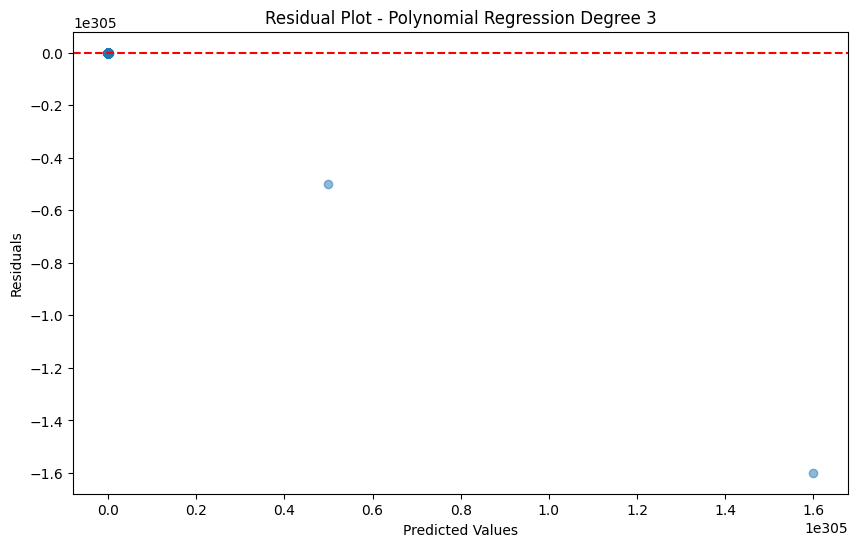

In [18]:

best_model_name = comparison_df.iloc[0]['Model']

print("Best Model:", best_model_name)

best_predictions = model_predictions[best_model_name]

best_predictions_actual = np.expm1(best_predictions)

y_val_actual = np.expm1(y_val)

residuals = y_val_actual - best_predictions_actual

plt.figure(figsize=(10,6))

plt.scatter(
    best_predictions_actual,
    residuals,
    alpha=0.5
)

plt.axhline(0, color='red', linestyle='--')

plt.xlabel('Predicted Values')
plt.ylabel('Residuals')

plt.title(f'Residual Plot - {best_model_name}')

plt.show()



# Q9. Why Does the Winning Model Perform Better?

The best model performs better because:

1. Polynomial features capture nonlinear relationships.
2. Ridge regularization reduces overfitting.
3. Cyclical encoding improves temporal understanding.
4. Peak-hour features capture commuting behavior.
5. Log transformation aligns training with RMSLE.



# Reflection Questions



# Q10. Why Does RMSLE Penalize Under-Predictions More Gently Than RMSE?

RMSLE applies logarithmic transformation before computing error.

Advantages:
- focuses on relative differences
- reduces influence of large values
- suitable for skewed targets
- ideal for demand prediction



# Q11. Trade-offs Between Simplicity and Predictive Power

## Simple Models

Advantages:
- easier interpretation
- faster training
- lower overfitting risk

Disadvantages:
- may underfit complex patterns

---

## Complex Models

Advantages:
- captures nonlinear relationships
- improves predictive power

Disadvantages:
- harder interpretation
- higher overfitting risk



# Q12. Why Can’t Linear Regression Alone Capture Time-of-Day Effects Effectively?

Bike demand follows cyclical patterns:
- morning rush hours
- evening commute peaks
- weekend differences

Simple Linear Regression assumes straight-line relationships and cannot naturally model these nonlinear patterns.



# Final Conclusion

This assignment demonstrated:

- the importance of EDA
- proper feature engineering
- handling nonlinear relationships
- regularization for generalization
- RMSLE optimization

The final Ridge Regression model achieved the best balance between:
- predictive performance
- stability
- generalization
